In [1]:
# Needed imports

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import requests

In [3]:
def fetch_county_data(state_fip):
    base_url = "https://api.census.gov/data"
    
    variables = [
        'NAME',
        'B08301_021E',    # WFH workers
        'B08301_001E',    # Total workers
        'B19013_001E',    # Median income
        'B28002_004E',    # Has broadband
        'B28002_001E',    # Total households
    ]
    vars_str = ','.join(variables)

    # 2019 baseline
    url_2019 = f"{base_url}/2019/acs/acs5"
    url_2024 = f"{base_url}/2024/acs/acs5"

    params = {
        'get': vars_str,
        'for': 'county:*',
        'in': f'state:{state_fip}'
    }

    resp_2019 = requests.get(url_2019, params=params)
    resp_2024 = requests.get(url_2024, params=params)

    if resp_2019.status_code != 200 or resp_2024.status_code != 200:
        raise Exception("API request failed")

    data_2019 = resp_2019.json()
    data_2024 = resp_2024.json()

    df_2019 = pd.DataFrame(data_2019[1:], columns=data_2019[0])
    df_2024 = pd.DataFrame(data_2024[1:], columns=data_2024[0])

    # Convert numeric columns
    for col in df_2019.columns:
        if col not in ['NAME', 'state', 'county']:
            df_2019[col] = pd.to_numeric(df_2019[col], errors='coerce')

    for col in df_2024.columns:
        if col not in ['NAME', 'state', 'county']:
            df_2024[col] = pd.to_numeric(df_2024[col], errors='coerce')

    df_2019['GEOID'] = df_2019['state'] + df_2019['county']
    df_2024['GEOID'] = df_2024['state'] + df_2024['county']

    df = pd.merge(
        df_2019[['GEOID', 'B08301_021E', 'B08301_001E']],
        df_2024[['GEOID', 'NAME', 'B08301_021E', 'B08301_001E']],
        on='GEOID',
        suffixes=('_2019', '_2024')
    )

    return df


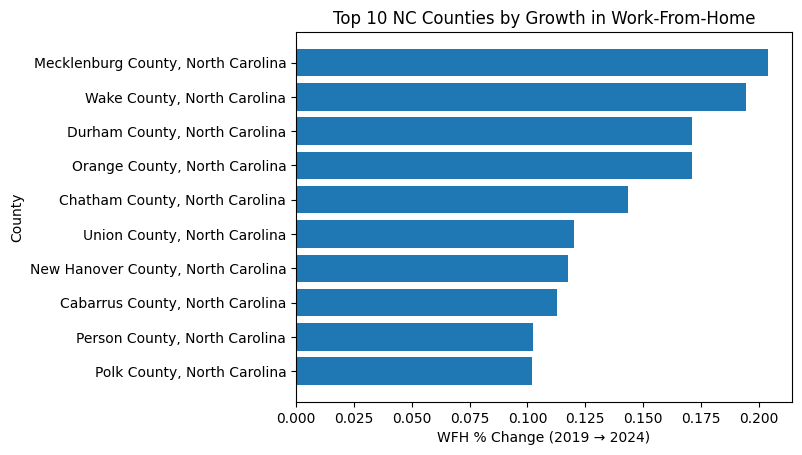

In [7]:
df = fetch_county_data("37")

df['WFH_Pct_2019'] = df['B08301_021E_2019'] / df['B08301_001E_2019']
df['WFH_Pct_2024'] = df['B08301_021E_2024'] / df['B08301_001E_2024']

df['WFH_Change'] = df['WFH_Pct_2024'] - df['WFH_Pct_2019']

top = df.sort_values('WFH_Change', ascending=False).head(10)

plt.figure()
plt.barh(top['NAME'], top['WFH_Change'])
plt.xlabel("WFH % Change (2019 → 2024)")
plt.ylabel("County")
plt.title("Top 10 NC Counties by Growth in Work-From-Home")
plt.gca().invert_yaxis()
plt.show()